<a href="https://colab.research.google.com/github/4GeeksAcademy/retnarou-algorithm-optimization-project-machine-learning/blob/main/K_nearest_neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data_url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
wine_df = pd.read_csv(data_url, sep=";")

wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
def map_quality_to_class(value):
    if value <= 4:
        return 0  # low
    elif value <= 6:
        return 1  # medium
    else:
        return 2  # high

wine_df["quality_label"] = wine_df["quality"].apply(map_quality_to_class)

In [3]:
features = wine_df.drop(columns=["quality", "quality_label"])
target = wine_df["quality_label"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

predictions = knn_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.84375

Confusion Matrix:
 [[  0  11   0]
 [  1 250  11]
 [  0  27  20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.87      0.95      0.91       262
           2       0.65      0.43      0.51        47

    accuracy                           0.84       320
   macro avg       0.50      0.46      0.47       320
weighted avg       0.81      0.84      0.82       320



In [8]:
import numpy as np

k_values = list(range(1, 21))
accuracy_scores = []

for k in k_values:
    temp_model = KNeighborsClassifier(n_neighbors=k)
    temp_model.fit(X_train_scaled, y_train)

    temp_preds = temp_model.predict(X_test_scaled)
    acc = accuracy_score(y_test, temp_preds)

    accuracy_scores.append(acc)

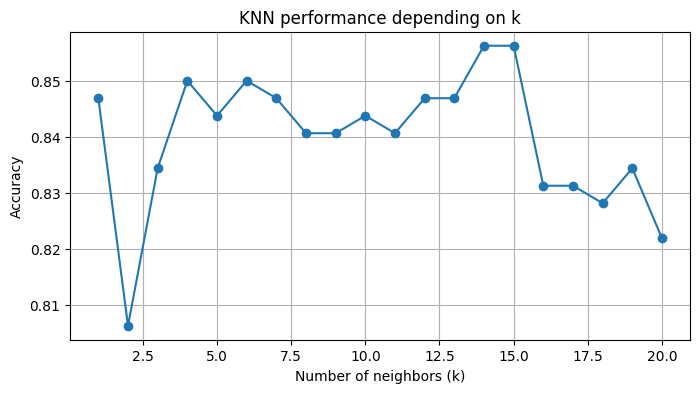

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracy_scores, marker="o")
plt.title("KNN performance depending on k")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [10]:
optimal_k = k_values[np.argmax(accuracy_scores)]
print("Optimal k:", optimal_k)

Optimal k: 14


In [11]:
final_model = KNeighborsClassifier(n_neighbors=optimal_k)
final_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=14)

In [12]:
def predict_wine(sample):
    scaled_sample = scaler.transform([sample])
    prediction = final_model.predict(scaled_sample)[0]

    if prediction == 0:
        return "Predicted: Low quality wine 🍷"
    elif prediction == 1:
        return "Predicted: Medium quality wine 🍷"
    else:
        return "Predicted: High quality wine 🍷"

In [13]:
test_sample = [7.4, 0.7, 0.0, 1.9, 0.076,
               11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]

print(predict_wine(test_sample))

Predicted: Medium quality wine 🍷


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
